In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix

In [2]:
#load data 
base = Path.cwd()
if not (base / "data").exists():
    base = base.parent

X_train = pd.read_csv(base / "data/processed/train/X_train.csv")
X_val   = pd.read_csv(base / "data/processed/val/X_val.csv")
X_test  = pd.read_csv(base / "data/processed/test/X_test.csv")

y_train = pd.read_csv(base / "data/processed/train/y_train.csv").values.ravel()
y_val   = pd.read_csv(base / "data/processed/val/y_val.csv").values.ravel()
y_test  = pd.read_csv(base / "data/processed/test/y_test.csv").values.ravel()

feature_names = X_train.columns.tolist()
N_FEATURES = len(feature_names)
print(f"Features: {N_FEATURES}, Train: {len(X_train)}, Val: {len(X_val)}")


Features: 78, Train: 1427431, Val: 356858


In [3]:
SAMPLE_SIZE = 50000
np.random.seed(42)
idx = np.random.choice(len(X_train), SAMPLE_SIZE, replace=False)

X_sample = X_train.iloc[idx]
y_sample = y_train[idx]

print(f"Using {SAMPLE_SIZE} samples for GA fitness evaluation")
print(f"Class balance: {y_sample.mean():.2%} attack")

Using 50000 samples for GA fitness evaluation
Class balance: 24.73% attack


In [4]:
POP_SIZE      = 20      # number of chromosomes
N_GENERATIONS = 15      # number of generations
MUTATION_RATE = 0.05    # probability of flipping each bit
CROSSOVER_RATE = 0.8    # probability of crossover
MIN_FEATURES  = 5       # at least 5 features must be selected

random.seed(42)
np.random.seed(42)

In [5]:
def create_chromosome():
    """Random binary chromosome — ensure at least MIN_FEATURES selected."""
    chrom = np.zeros(N_FEATURES, dtype=int)
    selected = np.random.choice(N_FEATURES, MIN_FEATURES, replace=False)
    chrom[selected] = 1
    # randomly activate ~50% of remaining features
    for i in range(N_FEATURES):
        if chrom[i] == 0 and random.random() < 0.5:
            chrom[i] = 1
    return chrom

def fitness(chromosome):
    """Train RF on selected features, return F1 on validation sample."""
    selected = np.where(chromosome == 1)[0]
    if len(selected) < MIN_FEATURES:
        return 0.0  # penalise invalid chromosomes

    clf = RandomForestClassifier(
        n_estimators=50,   # small for speed during GA
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_sample.iloc[:, selected], y_sample)

    # evaluate on full validation set
    y_pred = clf.predict(X_val.iloc[:, selected])
    return f1_score(y_val, y_pred)

def tournament_selection(population, scores, k=3):
    """Pick best from k random candidates."""
    candidates = random.sample(range(len(population)), k)
    best = max(candidates, key=lambda i: scores[i])
    return population[best].copy()

def crossover(parent1, parent2):
    """Single-point crossover."""
    if random.random() > CROSSOVER_RATE:
        return parent1.copy(), parent2.copy()
    point = random.randint(1, N_FEATURES - 1)
    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])
    return child1, child2

def mutate(chromosome):
    """Flip each bit with MUTATION_RATE probability."""
    child = chromosome.copy()
    for i in range(N_FEATURES):
        if random.random() < MUTATION_RATE:
            child[i] = 1 - child[i]
    # ensure minimum features
    if child.sum() < MIN_FEATURES:
        extra = np.random.choice(np.where(child == 0)[0], MIN_FEATURES - child.sum(), replace=False)
        child[extra] = 1
    return child


In [6]:
print("=" * 50)
print("Running Genetic Algorithm...")
print("=" * 50)

start_time = time.time()

# Initialise population
population = [create_chromosome() for _ in range(POP_SIZE)]

best_chromosome = None
best_score = -1
history = []  # track best F1 per generation

for gen in range(N_GENERATIONS):
    gen_start = time.time()

    # Evaluate fitness for all chromosomes
    scores = [fitness(chrom) for chrom in population]

    # Track best
    gen_best_idx = np.argmax(scores)
    gen_best_score = scores[gen_best_idx]

    if gen_best_score > best_score:
        best_score = gen_best_score
        best_chromosome = population[gen_best_idx].copy()

    history.append({
        "generation": gen + 1,
        "best_f1": gen_best_score,
        "avg_f1": np.mean(scores),
        "n_features": int(population[gen_best_idx].sum())
    })

    gen_time = time.time() - gen_start
    print(f"Gen {gen+1:2d}/{N_GENERATIONS} | Best F1: {gen_best_score:.4f} | "
          f"Avg F1: {np.mean(scores):.4f} | "
          f"Features: {int(population[gen_best_idx].sum())} | "
          f"Time: {gen_time:.1f}s")

    # Create next generation
    new_population = []

    # Elitism — keep top 2
    top2 = np.argsort(scores)[-2:]
    new_population.extend([population[i].copy() for i in top2])

    # Fill rest with crossover + mutation
    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population, scores)
        p2 = tournament_selection(population, scores)
        c1, c2 = crossover(p1, p2)
        new_population.append(mutate(c1))
        if len(new_population) < POP_SIZE:
            new_population.append(mutate(c2))

    population = new_population

total_time = time.time() - start_time
print(f"\nGA completed in {total_time:.1f}s")
print(f"Best F1 (on val): {best_score:.4f}")
print(f"Features selected: {int(best_chromosome.sum())} / {N_FEATURES}")

Running Genetic Algorithm...
Gen  1/15 | Best F1: 0.9900 | Avg F1: 0.9830 | Features: 42 | Time: 19.4s
Gen  2/15 | Best F1: 0.9905 | Avg F1: 0.9883 | Features: 42 | Time: 18.6s
Gen  3/15 | Best F1: 0.9911 | Avg F1: 0.9893 | Features: 40 | Time: 18.9s
Gen  4/15 | Best F1: 0.9911 | Avg F1: 0.9895 | Features: 40 | Time: 18.6s
Gen  5/15 | Best F1: 0.9911 | Avg F1: 0.9895 | Features: 40 | Time: 18.2s
Gen  6/15 | Best F1: 0.9919 | Avg F1: 0.9899 | Features: 34 | Time: 18.3s
Gen  7/15 | Best F1: 0.9919 | Avg F1: 0.9903 | Features: 34 | Time: 18.0s
Gen  8/15 | Best F1: 0.9927 | Avg F1: 0.9899 | Features: 30 | Time: 17.3s
Gen  9/15 | Best F1: 0.9927 | Avg F1: 0.9899 | Features: 30 | Time: 17.0s
Gen 10/15 | Best F1: 0.9927 | Avg F1: 0.9894 | Features: 30 | Time: 17.8s
Gen 11/15 | Best F1: 0.9927 | Avg F1: 0.9898 | Features: 30 | Time: 21.3s
Gen 12/15 | Best F1: 0.9927 | Avg F1: 0.9901 | Features: 30 | Time: 20.1s
Gen 13/15 | Best F1: 0.9927 | Avg F1: 0.9902 | Features: 30 | Time: 19.7s
Gen 14/15

In [7]:
selected_features = np.where(best_chromosome == 1)[0]
selected_names = [feature_names[i] for i in selected_features]

print(f"\nSelected {len(selected_names)} features:")
print(selected_names)

final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train.iloc[:, selected_features], y_train)
y_pred = final_model.predict(X_test.iloc[:, selected_features])

# Cell 8 — Evaluate
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("=" * 45)
print("GA + RF RESULTS")
print("=" * 45)
print(f"Accuracy:            {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision:           {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Det. Rate):  {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:            {f1_score(y_test, y_pred):.4f}")
print(f"False Positive Rate: {fp / (fp + tn):.4f}")
print(f"Features Used:       {len(selected_features)} / {N_FEATURES}")
print(f"\nConfusion Matrix:\n{cm}")


Selected 36 features:
['destination_port', 'flow_duration', 'total_length_of_fwd_packets', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'flow_bytes/s', 'flow_iat_std', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_min', 'bwd_iat_max', 'bwd_iat_min', 'fwd_packets/s', 'max_packet_length', 'packet_length_mean', 'fin_flag_count', 'syn_flag_count', 'psh_flag_count', 'urg_flag_count', 'ece_flag_count', 'avg_bwd_segment_size', 'fwd_header_length.1', 'fwd_avg_packets/bulk', 'fwd_avg_bulk_rate', 'bwd_avg_packets/bulk', 'subflow_fwd_packets', 'subflow_bwd_packets', 'subflow_bwd_bytes', 'init_win_bytes_forward', 'init_win_bytes_backward', 'active_mean', 'idle_mean', 'idle_std', 'idle_max']
GA + RF RESULTS
Accuracy:            0.7928
Precision:           0.9991
Recall (Det. Rate):  0.6353
F1-Score:            0.7767
False Positive Rate: 0.0008
Features Used:       36 / 78

Confusion Matrix:
[[97610    76]
 [46695 81330]]


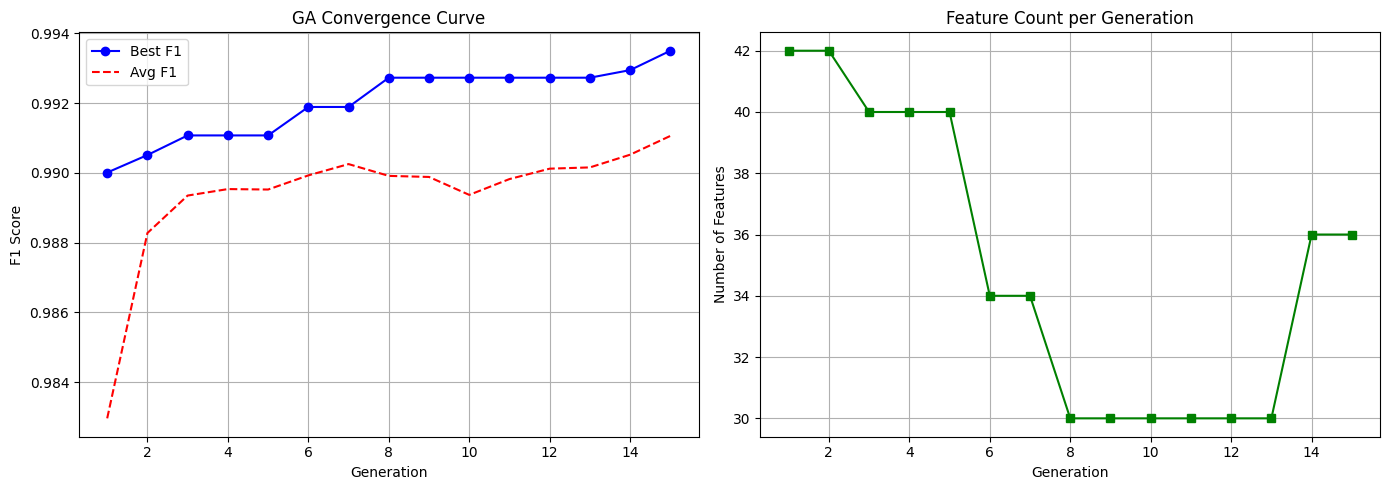

GA results saved.


In [8]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence curve
axes[0].plot(history_df["generation"], history_df["best_f1"], "b-o", label="Best F1")
axes[0].plot(history_df["generation"], history_df["avg_f1"], "r--", label="Avg F1")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("F1 Score")
axes[0].set_title("GA Convergence Curve")
axes[0].legend()
axes[0].grid(True)

# Feature count per generation
axes[1].plot(history_df["generation"], history_df["n_features"], "g-s")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Number of Features")
axes[1].set_title("Feature Count per Generation")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("ga_convergence.png", dpi=150)
plt.show()

# Cell 10 — Save results for comparison notebook
ga_results = {
    "method": "GA",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "fpr": fp / (fp + tn),
    "n_features": len(selected_features),
    "runtime_s": total_time
}

pd.DataFrame([ga_results]).to_csv(base / "data/processed/ga_results.csv", index=False)
np.save(base / "data/processed/ga_selected_features.npy", selected_features)
print("GA results saved.")